In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
from h5py import File


import sys
sys.path.append("../")

%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
# Load CF4 data
CF4 = np.load("/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_cepheids_processed.npy", allow_pickle=True)
cf4_names = CF4["name"].astype(str)
cf4_pgcs = CF4["pgc"]
cf4_dm21 = CF4["DM21"]
cf4_eDM = CF4["e_DM"]

# Load SH0ES data
with File("/mnt/extraspace/rstiskalek/catalogs/SH0ES/SH0ES_samples.hdf5", 'r') as f:
    mu_SH0ES = {key: f[key][...] for key in f.keys() if key.startswith("mu_")}

# Manual name corrections: SH0ES_name -> CF4_name
manual_map = {
    "M101": "N5457",
    "M31": "N0224",
    "Mrk_1337": "M1337",
    "N0105": "N105",
    "N0691": "N691",
    "N0976": "N976"
}

# Extract SH0ES names (no 'mu_' prefix)
shoes_names = [key[3:] for key in mu_SH0ES]

# Match SH0ES to CF4 with correction map
pgc_dm21_table = []

for shoes_name in shoes_names:
    cf4_name = manual_map.get(shoes_name, shoes_name)
    match_idx = np.where(cf4_names == cf4_name)[0]
    if match_idx.size > 0:
        idx = match_idx[0]
        pgc = cf4_pgcs[idx]
        dm21 = cf4_dm21[idx]
        e_DM = cf4_eDM[idx]
        pgc_dm21_table.append((shoes_name, cf4_name, pgc, dm21, e_DM))

# Print results
for shoes_name, cf4_name, pgc, dm21, __ in pgc_dm21_table:
    print(f"SH0ES: {shoes_name:10s} → CF4: {cf4_name:8s} | PGC: {pgc:6d} | DM21: {dm21:.3f}")


SH0ES: M101       → CF4: N5457    | PGC:  50063 | DM21: 29.178
SH0ES: M1337      → CF4: M1337    | PGC:  43690 | DM21: 32.920
SH0ES: M31        → CF4: N0224    | PGC:   2557 | DM21: 24.397
SH0ES: N0105      → CF4: N105     | PGC:   1583 | DM21: 34.527
SH0ES: N0691      → CF4: N691     | PGC:   6793 | DM21: 32.830
SH0ES: N0976      → CF4: N976     | PGC:   9776 | DM21: 33.709
SH0ES: N1015      → CF4: N1015    | PGC:   9988 | DM21: 32.563
SH0ES: N1309      → CF4: N1309    | PGC:  12626 | DM21: 32.541
SH0ES: N1365      → CF4: N1365    | PGC:  13179 | DM21: 31.378
SH0ES: N1448      → CF4: N1448    | PGC:  13727 | DM21: 31.287
SH0ES: N1559      → CF4: N1559    | PGC:  14814 | DM21: 31.491
SH0ES: N2442      → CF4: N2442    | PGC:  21373 | DM21: 31.450
SH0ES: N2525      → CF4: N2525    | PGC:  22721 | DM21: 32.051
SH0ES: N2608      → CF4: N2608    | PGC:  24111 | DM21: 32.612
SH0ES: N3021      → CF4: N3021    | PGC:  28357 | DM21: 32.464
SH0ES: N3147      → CF4: N3147    | PGC:  30019 | DM21:

In [4]:
x, y = [], []
xerr, yerr = [], []

pgc_selected = []
names_selected = []
samples_selected = []
for shoes_name, cf4_name, pgc, dm21, e_dm in pgc_dm21_table:
    x.append(dm21)
    y.append(mu_SH0ES[f"mu_{shoes_name}"].mean(axis=0))

    xerr.append(e_dm)
    yerr.append(mu_SH0ES[f"mu_{shoes_name}"].std(axis=0))

    pgc_selected.append(pgc)
    names_selected.append(shoes_name)
    samples_selected.append(mu_SH0ES[f"mu_{shoes_name}"])

x, y = np.array(x), np.array(y)
xerr, yerr = np.array(xerr), np.array(yerr)

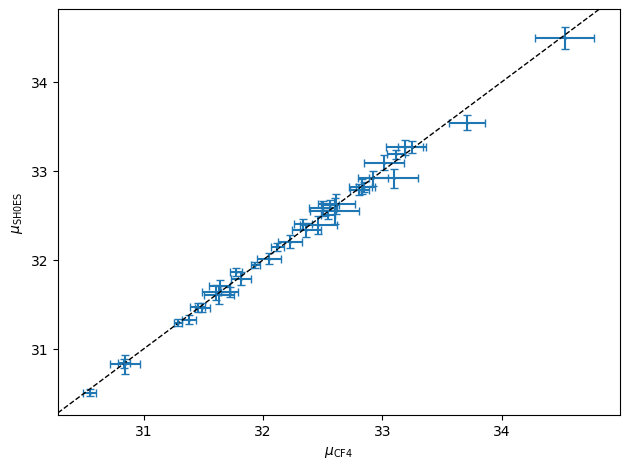

In [5]:
m = x > 30

plt.figure()
# plt.scatter(x, y)
plt.errorbar(x[m], y[m], xerr=xerr[m], yerr=yerr[m], fmt='o', capsize=3, ms=1)

plt.axline([np.mean(x), np.mean(x)], slope=1, color="k", ls="--", lw=1)
plt.xlabel(r"$\mu_{\mathrm{CF4}}$")
plt.ylabel(r"$\mu_{\mathrm{SH0ES}}$")
plt.tight_layout()
plt.savefig("cf4_shoes_mu.png", dpi=300, bbox_inches="tight")
plt.show()

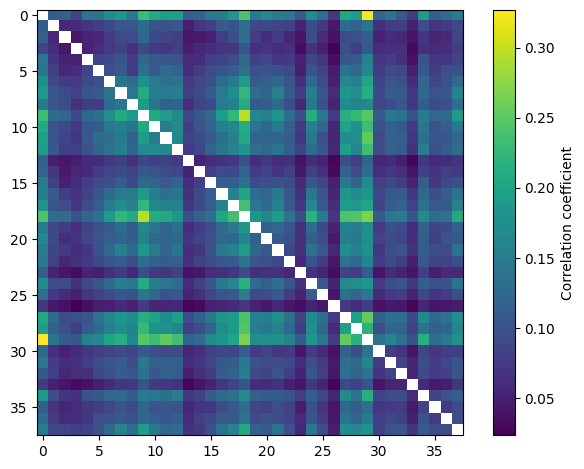

In [6]:
X = np.vstack([mu_SH0ES[key] for key in mu_SH0ES.keys() if key.startswith("mu_")]).T
C = np.cov(X, rowvar=False)
correlation_matrix = C / np.sqrt(np.outer(np.diag(C), np.diag(C)))

correlation_matrix[correlation_matrix==1.] = np.nan


plt.figure()
plt.imshow(correlation_matrix)
plt.colorbar(label="Correlation coefficient")
plt.tight_layout()
plt.savefig("cf4_shoes_mu_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
X = np.vstack(samples_selected).T
C = np.cov(X, rowvar=False)

fname = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4_SH0ES_calibration.hdf5"
with File(fname, 'w') as f:
    f.create_dataset("distmod_samples", data=X)
    f.create_dataset("distmod_mean", data=np.mean(X, axis=0))
    f.create_dataset("distmod_covariance", data=C)
    f.create_dataset("pgc", data=np.array(pgc_selected))
    f.create_dataset("names", data=np.array(names_selected, dtype="S"))


In [8]:
with File("/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_TF-distances.hdf5", 'r') as f:
    print(f.keys())
    pgc_CF4 = f["1PGC"][...]
    w1 = f["w1"][...]
    Qw = f["Qw"][...]
    zcmb = f["Vcmb"][...] / 299_792.458
    RA = f["RA"][...] * 360 / 24
    dec = f["DE"][...]
m = (w1 > 5) & (Qw == 5) & (zcmb < 0.05)
# m = (zcmb < 0.05)
pgc_CF4 = pgc_CF4[m]


<KeysViewHDF5 ['1PGC', 'DE', 'DM_so', 'DM_w1', 'DM_w1_raw', 'DM_w1_rms', 'DMbest', 'DMi', 'DMi_raw', 'DMi_rms', 'DMr', 'DMr_raw', 'DMr_rms', 'DMz', 'DMz_raw', 'DMz_rms', 'GLat', 'GLong', 'N15', 'Nest', 'Nkt', 'P1_W2', 'Qs', 'Qw', 'RA', 'R_so', 'SGB', 'SGBg', 'SGL', 'SGLg', 'Vcmb', 'Vh', 'Vls', 'Vmodg', 'eDM_w1', 'eDMbest', 'eDMi', 'eDMr', 'eDMstat', 'eDMz', 'elgWi', 'f', 'g', 'i', 'inc', 'lgWmxi', 'not_matched_to_2MTF_or_SFI', 'pgc', 'r', 'w1', 'w2', 'z']>


In [15]:
import csiborgtools

csiborgtools.hms_to_degrees(12, 59, 48.7), csiborgtools.dms_to_degrees(27, 58, 50)


(194.95291666666665, 27.980555555555554)

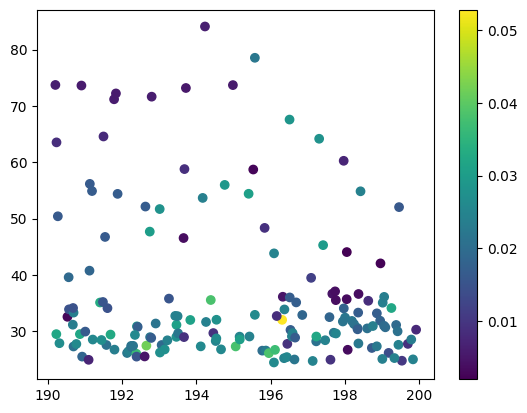

In [20]:
m = (RA > 190) & (RA < 200)

m &= dec > 24

plt.figure()
plt.scatter(RA[m], dec[m], c=zcmb[m])
plt.colorbar()



plt.show()



In [4]:
np.isin(pgc_selected, pgc_CF4).sum()

NameError: name 'pgc_selected' is not defined

In [31]:
ids = [9332, 13602, 13727, 14814, 17819, 21396, 22721, 23110, 24111, 26512,
       28357, 28630, 31671, 32192, 32207, 34695, 37466, 39600, 41823, 52521,
       54097, 69327]

In [36]:
m = np.isin(pgc_selected, ids)

In [45]:
Cnew = C[m][:, m]
Cnew = Cnew / np.sqrt(np.outer(np.diag(Cnew), np.diag(Cnew)))
Cnew[Cnew==1.] = np.nan

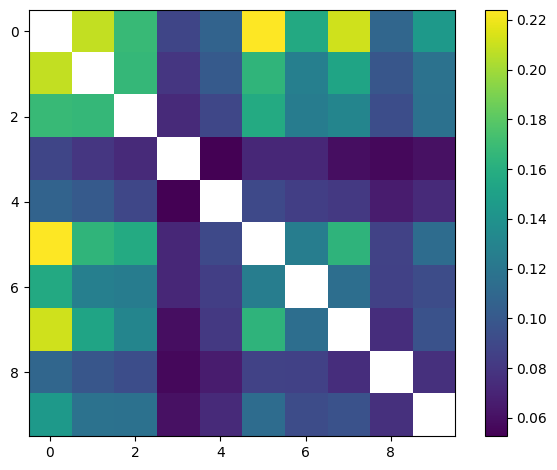

In [47]:
plt.figure()
plt.imshow(Cnew)
plt.colorbar()
# plt.colorbar(label="Correlation coefficient")
plt.tight_layout()
# plt.savefig("cf4_shoes_mu_correlation_selected.png", dpi=300, bbox_inches="tight")
plt.show()

In [34]:
m.sum()

10